In [ ]:
import sys
import numpy as np
from pathlib import Path

BSF_ROOT = Path("/ebs/home/lily_switch_box/buildstock-fetch")
RDP_ROOT = Path("/ebs/home/lily_switch_box/rate-design-platform")

# Both repos have a top-level `utils/` package — only one can be cached as `utils`.
# Put buildstock-fetch first so `from utils import ev_utils` works.
# Import rate-design-platform's utils.loads via importlib in the next cell.
for root in (RDP_ROOT, BSF_ROOT):
    root_str = str(root)
    if root_str in sys.path:
        sys.path.remove(root_str)
sys.path.insert(0, str(BSF_ROOT))
sys.path.insert(1, str(RDP_ROOT))

In [2]:
from pathlib import Path

import polars as pl

from data.eia.hourly_loads.eia_region_config import get_aws_storage_options

# ── Edit these ──────────────────────────────────────────────────────────────
STATE = "MD"
UPGRADE = "00"          # try "02" later for the heat-pump upgrade
USE_LOCAL = True        # False → read from s3://data.sb/...
USE_SB = True           # False → raw NREL metadata.parquet
SEED = 42
# ────────────────────────────────────────────────────────────────────────────

RELEASE = "res_2024_amy2018_2"
RELEASE_SB = f"{RELEASE}_sb"
PATH_LOCAL = Path("/ebs/data/nrel/resstock")
PATH_S3 = "s3://data.sb/nrel/resstock"

release_name = RELEASE_SB if USE_SB else RELEASE
resstock_base = (
    PATH_LOCAL / release_name if USE_LOCAL else f"{PATH_S3}/{release_name}"
)
storage_options = get_aws_storage_options() if not USE_LOCAL else None
meta_filename = "metadata-sb.parquet" if USE_SB else "metadata.parquet"

path_metadata = (
    f"{resstock_base}/metadata/state={STATE}/upgrade={UPGRADE}/{meta_filename}"
)
path_loads_dir = (
    f"{resstock_base}/load_curve_hourly/state={STATE}/upgrade={UPGRADE}"
)

print(f"Metadata:  {path_metadata}")
print(f"Loads dir: {path_loads_dir}")

Metadata:  /ebs/data/nrel/resstock/res_2024_amy2018_2_sb/metadata/state=MD/upgrade=00/metadata-sb.parquet
Loads dir: /ebs/data/nrel/resstock/res_2024_amy2018_2_sb/load_curve_hourly/state=MD/upgrade=00


In [3]:
# load metadata
kwargs = {"storage_options": storage_options} if storage_options else {}
metadata = pl.read_parquet(path_metadata, **kwargs)

print(f"{metadata.height:,} buildings × {metadata.width} columns")
metadata.head(3)

9,996 buildings × 188 columns


upgrade,weight,in.sqft,in.representative_income,in.ahs_region,in.aiannh_area,in.area_median_income,in.ashrae_iecc_climate_zone_2004,in.ashrae_iecc_climate_zone_2004_2_a_split,in.bathroom_spot_vent_hour,in.battery,in.bedrooms,in.building_america_climate_zone,in.cec_climate_zone,in.ceiling_fan,in.census_division,in.census_division_recs,in.census_region,in.city,in.clothes_dryer,in.clothes_dryer_usage_level,in.clothes_washer,in.clothes_washer_presence,in.clothes_washer_usage_level,in.cooking_range,in.cooking_range_usage_level,in.cooling_setpoint,in.cooling_setpoint_has_offset,in.cooling_setpoint_offset_magnitude,in.cooling_setpoint_offset_period,in.corridor,in.county,in.county_and_puma,in.county_name,in.dehumidifier,in.dishwasher,in.dishwasher_usage_level,…,in.solar_hot_water,in.state,in.tenure,in.units_represented,in.usage_level,in.utility_bill_electricity_fixed_charges,in.utility_bill_electricity_marginal_rates,in.utility_bill_fuel_oil_fixed_charges,in.utility_bill_fuel_oil_marginal_rates,in.utility_bill_natural_gas_fixed_charges,in.utility_bill_natural_gas_marginal_rates,in.utility_bill_propane_fixed_charges,in.utility_bill_propane_marginal_rates,in.utility_bill_scenario_names,in.utility_bill_simple_filepaths,in.vacancy_status,in.vintage,in.vintage_acs,in.water_heater_efficiency,in.water_heater_fuel,in.water_heater_in_unit,in.water_heater_location,in.weather_file_city,in.weather_file_latitude,in.weather_file_longitude,in.window_areas,in.windows,bldg_id,postprocess_group.has_hp,postprocess_group.heating_type,postprocess_group.heating_type_v2,heats_with_electricity,heats_with_natgas,heats_with_oil,heats_with_propane,has_natgas_connection,mf_non_hvac_electricity_adjusted
i64,f64,i64,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,…,str,str,str,i64,str,i64,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,f64,f64,str,str,i64,bool,str,str,bool,bool,bool,bool,bool,bool
0,252.301639,1682,108692.0,"""Non-CBSA South Atlantic""","""No""","""120-150%""","""4A""","""4A""","""Hour6""","""None""","""3""","""Mixed-Humid""","""None""","""Standard Efficiency""","""South Atlantic""","""South Atlantic""","""South""","""In another census Place""","""None""","""120% Usage""","""None""","""None""","""120% Usage""","""Electric Resistance""","""120% Usage""","""72F""","""No""","""0F""","""None""","""Double-Loaded Interior""","""G2400030""","""G2400030, G24001202""","""Anne Arundel County""","""None""","""290 Rated kWh""","""120% Usage""",…,"""None""","""MD""","""Renter""",1,"""High""",10,0.130352,"""0""","""3.219615385""","""11.25""","""1.217491908""","""0""","""3.224769231""","""Utility Rates - Fixed + Variab…","""data/simple_rates/State.tsv""","""Occupied""","""1980s""","""1980-99""","""Electric Standard""","""Electricity""","""No""","""None""","""Baltimore Washingto""",39.17,-76.68,"""F18 B18 L18 R18""","""Single, Clear, Non-metal""",185465,false,"""electrical_resistance""","""electrical_resistance""",true,false,false,false,false,true
0,252.301639,854,108692.0,"""CBSA Washington-Arlington-Alex…","""No""","""100-120%""","""4A""","""4A""","""Hour22""","""None""","""2""","""Mixed-Humid""","""None""","""None""","""South Atlantic""","""South Atlantic""","""South""","""In another census Place""","""None""","""100% Usage""","""None""","""None""","""100% Usage""","""Electric Resistance""","""100% Usage""","""68F""","""No""","""0F""","""None""","""Double-Loaded Interior""","""G2400330""","""G2400330, G24001102""","""Prince George's County""","""None""","""318 Rated kWh""","""100% Usage""",…,"""None""","""MD""","""Renter""",1,"""Medium""",10,0.130352,"""0""","""3.219615385""","""11.25""","""1.217491908""","""0""","""3.224769231""","""Utility Rates - Fixed + Variab…","""data/simple_rates/State.tsv""","""Occupied""","""1970s""","""1960-79""","""Electric Heat Pump, 50 gal, 3.…","""Electricity""","""No""","""None""","""Andrews Afb Camp Sp""",38.82,-76.85,"""

Simple EV charging model:
- Every household has 1 EV with the same battery capacity
- Every household has the same EV charger
- Every household has the same miles traveled (30 miles per day at 0.3 kWh/mile → needs to charge 9 kWh at night)
- Assume same electricity rate for everyone and it is constant by hour
- Every household does all their charging at home (no differentiation by hour because rates are held constant)

In [4]:
# EV Assumptions
EVS_PER_HOUSEHOLD = 1
DAILY_MILES = 30
KWH_PER_MILE = 0.30
DAYS_PER_YEAR = 365

daily_kwh_per_ev = DAILY_MILES * KWH_PER_MILE
annual_kwh_per_ev = daily_kwh_per_ev * DAYS_PER_YEAR

ev_model_simple = (
    metadata.select(
        "bldg_id",
        "weight",
        "in.county_name",
        "in.income",
        "in.puma_metro_status",
        "in.utility_bill_electricity_marginal_rates",
    )
    .rename({"in.utility_bill_electricity_marginal_rates": "rate_per_kwh"})
    .with_columns(
        pl.lit(EVS_PER_HOUSEHOLD).alias("ev_count"),
        pl.lit(daily_kwh_per_ev).alias("daily_ev_kwh"),
        pl.lit(annual_kwh_per_ev).alias("annual_ev_kwh_per_ev"),
    )
    .with_columns(
        (pl.col("annual_ev_kwh_per_ev") * pl.col("ev_count")).alias("annual_ev_kwh"),
    )
    .with_columns(
        (pl.col("annual_ev_kwh") * pl.col("rate_per_kwh")).alias("annual_ev_cost_usd"),
    )
    .with_columns(
        (pl.col("annual_ev_kwh") * pl.col("weight")).alias("weighted_annual_ev_kwh"),
        (pl.col("annual_ev_cost_usd") * pl.col("weight")).alias("weighted_annual_ev_cost_usd"),
    )
)

ev_model_simple.head(5)

bldg_id,weight,in.county_name,in.income,in.puma_metro_status,rate_per_kwh,ev_count,daily_ev_kwh,annual_ev_kwh_per_ev,annual_ev_kwh,annual_ev_cost_usd,weighted_annual_ev_kwh,weighted_annual_ev_cost_usd
i64,f64,str,str,str,f64,i32,f64,f64,f64,f64,f64,f64
185465,252.301639,"""Anne Arundel County""","""100000-119999""","""In metro area, not/partially i…",0.130352,1,9.0,3285.0,3285.0,428.207506,828810.883229,108037.455451
381889,252.301639,"""Prince George's County""","""100000-119999""","""In metro area, not/partially i…",0.130352,1,9.0,3285.0,3285.0,428.207506,828810.883229,108037.455451
294937,252.301639,"""Baltimore city""","""100000-119999""","""In metro area, principal city""",0.130352,1,9.0,3285.0,3285.0,428.207506,828810.883229,108037.455451
310780,252.301639,"""Baltimore County""","""<10000""","""In metro area, not/partially i…",0.130352,1,9.0,3285.0,3285.0,428.207506,828810.883229,108037.455451
313723,252.301639,"""Harford County""","""50000-59999""","""In metro area, not/partially i…",0.130352,1,9.0,3285.0,3285.0,428.207506,828810.883229,108037.455451


Now add EV ownership model (ResStock publishes conditional probabilities of EV ownership based on fpl, building_type, PUMA, and tenure, which they calculate using the TEMPO base year (2023 Experian data) + RECS data to get relationships between housing characteristics)
- to expand to different adoption levels, would need to apply scaling or future scenarios from published TEMPO output

In [5]:
# read in NREL's EV ownership lookup (conditional probability of EV ownership given building type, tenure, PUMA, and FPL)
EV_OWNERSHIP_TSV = BSF_ROOT / "utils/ev_data/inputs/resstock_ev_reference/Electric_Vehicle_Ownership.tsv"
if not EV_OWNERSHIP_TSV.exists():
    raise FileNotFoundError(
        f"Missing {EV_OWNERSHIP_TSV}\nRun from repo root: just download-resstock-ev-reference"
    )

ev_lookup = (
    pl.read_csv(EV_OWNERSHIP_TSV, separator="\t")
    .rename({
        "Dependency=Federal Poverty Level": "fpl",
        "Dependency=Geometry Building Type RECS": "building_type",
        "Dependency=PUMA": "puma_dependency",
        "Dependency=Tenure": "tenure",
        "Option=Yes": "ev_ownership_probability",
    })
    .select(
        "fpl",
        "building_type",
        "puma_dependency",
        "tenure",
        "ev_ownership_probability",
        "source_weight",
    )
)

print(f"Lookup rows: {ev_lookup.height:,}")
ev_lookup.head(10)

Lookup rows: 246,867


fpl,building_type,puma_dependency,tenure,ev_ownership_probability,source_weight
str,str,str,str,f64,f64
"""0-100%""","""Mobile Home""","""AK, 00101""","""Not Available""",0.0,0.0
"""0-100%""","""Mobile Home""","""AK, 00101""","""Owner""",0.001357,651.315
"""0-100%""","""Mobile Home""","""AK, 00101""","""Renter""",0.003594,23.1579
"""100-150%""","""Mobile Home""","""AK, 00101""","""Not Available""",0.0,0.0
"""100-150%""","""Mobile Home""","""AK, 00101""","""Owner""",0.000007,52.1052
"""100-150%""","""Mobile Home""","""AK, 00101""","""Renter""",0.003594,86.842
"""150-200%""","""Mobile Home""","""AK, 00101""","""Not Available""",0.0,0.0
"""150-200%""","""Mobile Home""","""AK, 00101""","""Owner""",0.000004,150.526
"""150-200%""","""Mobile Home""","""AK, 00101""","""Renter""",0.003594,158.246


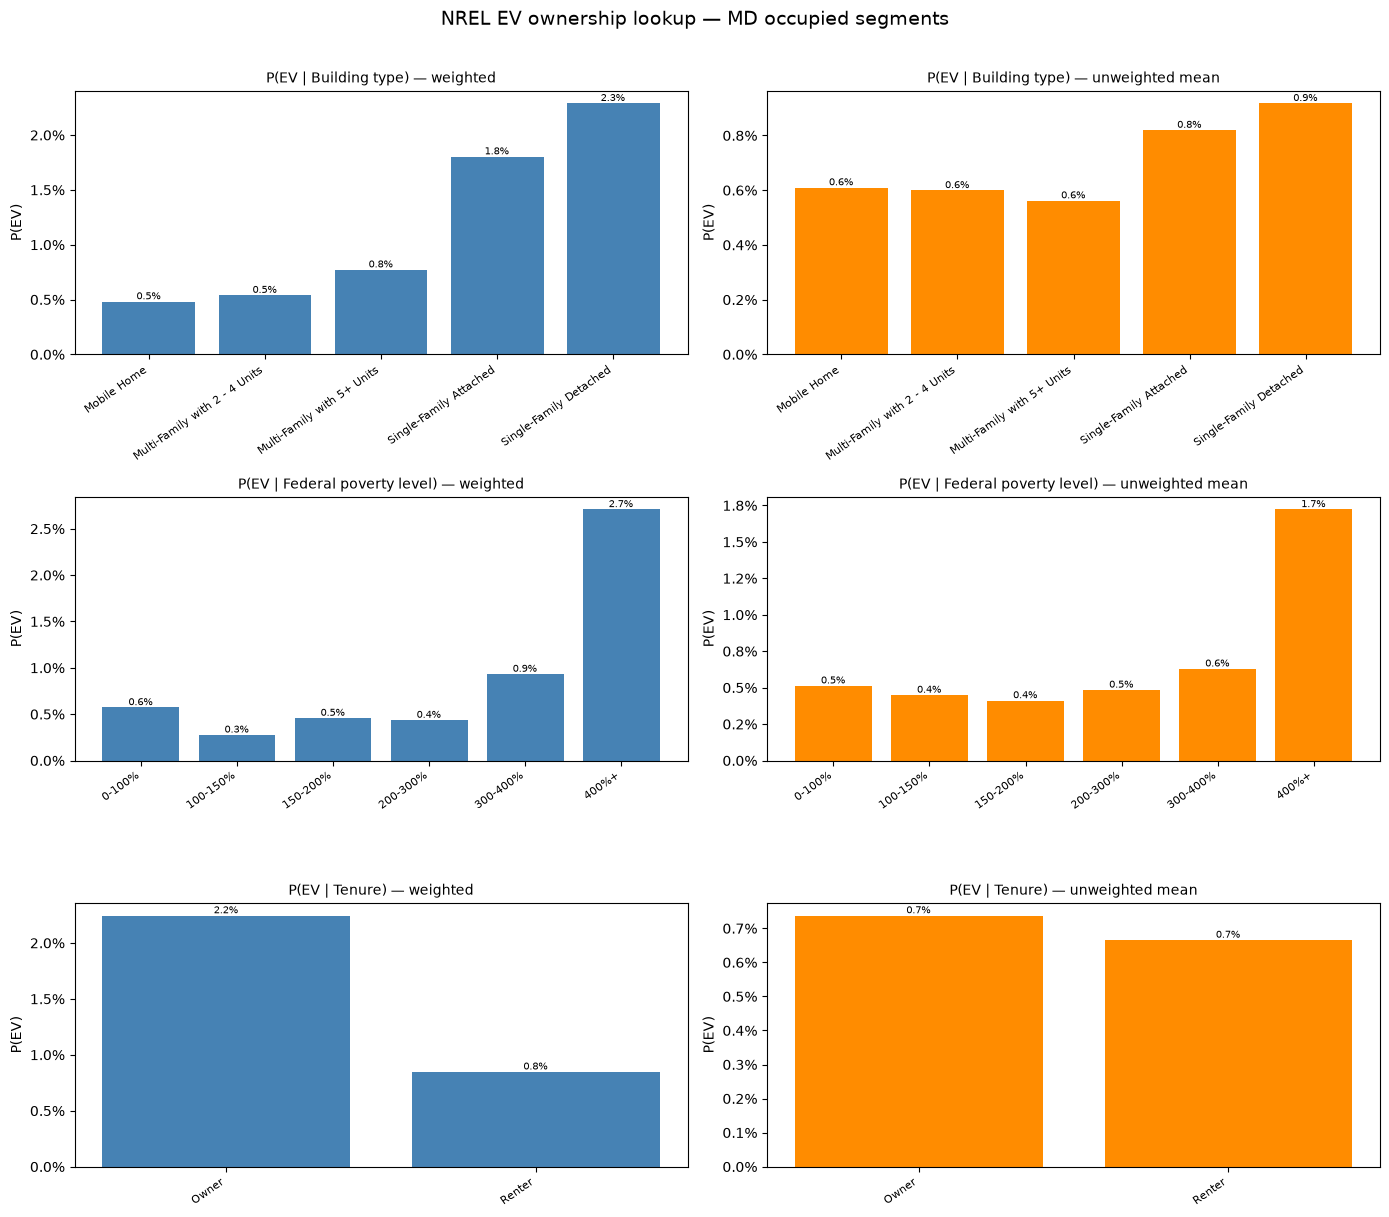

In [ ]:
import matplotlib.pyplot as plt

FPL_ORDER = ["0-100%", "100-150%", "150-200%", "200-300%", "300-400%", "400%+"]
PLOT_CATEGORIES = ["building_type", "fpl", "tenure"]
PLOT_CATEGORY_LABELS = {
    "building_type": "Building type",
    "fpl": "Federal poverty level",
    "tenure": "Tenure",
}

def ev_prob_summaries(
    df: pl.DataFrame,
    category: str,
    weight_col: str,
    prob_col: str = "ev_ownership_probability",
) -> pl.DataFrame:
    """Conditional = weight-weighted mean P(EV); categorical = unweighted mean across segments/buildings."""
    data = df.filter(
        (pl.col("tenure") != "Not Available")
        & (pl.col("fpl") != "Not Available")
        & (pl.col(category) != "Not Available")
    )
    prob = pl.col(prob_col).cast(pl.Float64)
    return (
        data.group_by(category)
        .agg(
            ((prob * pl.col(weight_col)).sum() / pl.col(weight_col).sum()).alias("conditional_p_ev"),
            prob.mean().alias("categorical_p_ev"),
            pl.col(weight_col).sum().alias("total_weight"),
            pl.len().alias("n"),
        )
    )


def _sort_summary(summary: pl.DataFrame, category: str) -> pl.DataFrame:
    if category == "fpl":
        order = {v: i for i, v in enumerate(FPL_ORDER)}
        return summary.sort(pl.col(category).replace(order))
    return summary.sort(category)


def plot_ev_probs_by_category(
    df: pl.DataFrame,
    *,
    weight_col: str,
    title: str,
    prob_col: str = "ev_ownership_probability",
) -> None:
    fig, axes = plt.subplots(3, 2, figsize=(14, 12))
    fig.suptitle(title, fontsize=14, y=1.01)

    for row, category in enumerate(PLOT_CATEGORIES):
        summary = _sort_summary(
            ev_prob_summaries(df, category, weight_col, prob_col), category
        )
        labels = summary[category].to_list()
        x = range(len(labels))

        panels = [
            ("conditional_p_ev", f"P(EV | {PLOT_CATEGORY_LABELS[category]}) — weighted"),
            ("categorical_p_ev", f"P(EV | {PLOT_CATEGORY_LABELS[category]}) — unweighted mean"),
        ]
        for col, (metric, subtitle) in enumerate(panels):
            ax = axes[row, col]
            vals = summary[metric].to_numpy()
            color = "steelblue" if col == 0 else "darkorange"
            bars = ax.bar(x, vals, color=color)
            ax.set_ylabel("P(EV)")
            ax.set_title(subtitle, fontsize=10)
            ax.set_xticks(list(x))
            ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=8)
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))
            for bar, val in zip(bars, vals):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height(),
                    f"{val:.1%}",
                    ha="center",
                    va="bottom",
                    fontsize=7,
                )

    fig.tight_layout()
    plt.show()


# NREL lookup — MD occupied segments only
md_ev_lookup_plot = ev_lookup.filter(
    pl.col("puma_dependency").str.starts_with(f"{STATE},")
)
plot_ev_probs_by_category(
    md_ev_lookup_plot,
    weight_col="source_weight",
    title=f"NREL EV ownership lookup — {STATE} occupied segments",
)


In [6]:
# filter ev_lookup for Maryland
md_ev_lookup = ev_lookup.filter(
    pl.col("puma_dependency").str.starts_with(f"{STATE},"),
)

print(f"MD lookup rows: {md_ev_lookup.height:,}")
print(f"P(EV) range in MD lookup: {md_ev_lookup['ev_ownership_probability'].min():.4f} – {md_ev_lookup['ev_ownership_probability'].max():.4f}")

# Not Available / null counts by category (lookup table only)
na_counts = pl.DataFrame({
    "category": [
        "tenure = Not Available",
        "fpl = Not Available (all tenures — includes zero-weight Owner/Renter placeholders)",
        "fpl = Not Available AND tenure = Not Available (vacant stock rows)",
        "building_type = Not Available",
        "puma_dependency = Not Available",
        "ev_ownership_probability is null",
        "source_weight is null or zero",
    ],
    "n": [
        md_ev_lookup.filter(pl.col("tenure") == "Not Available").height,
        md_ev_lookup.filter(pl.col("fpl") == "Not Available").height,
        md_ev_lookup.filter(
            (pl.col("tenure") == "Not Available")
            & (pl.col("fpl") == "Not Available")
        ).height,
        md_ev_lookup.filter(pl.col("building_type") == "Not Available").height,
        md_ev_lookup.filter(pl.col("puma_dependency") == "Not Available").height,
        md_ev_lookup.filter(pl.col("ev_ownership_probability").is_null()).height,
        md_ev_lookup.filter(
            pl.col("source_weight").is_null() | (pl.col("source_weight") == 0)
        ).height,
    ],
}).with_columns(
    (pl.col("n") / md_ev_lookup.height).alias("share_of_md_rows"),
)

print("\nNot Available / missing counts in MD lookup:")
print(na_counts)

MD lookup rows: 4,620
P(EV) range in MD lookup: 0.0000 – 0.0912

Not Available / missing counts in MD lookup:
shape: (7, 3)
┌─────────────────────────────────┬──────┬──────────────────┐
│ category                        ┆ n    ┆ share_of_md_rows │
│ ---                             ┆ ---  ┆ ---              │
│ str                             ┆ i64  ┆ f64              │
╞═════════════════════════════════╪══════╪══════════════════╡
│ tenure = Not Available          ┆ 1540 ┆ 0.333333         │
│ fpl = Not Available (all tenur… ┆ 660  ┆ 0.142857         │
│ fpl = Not Available AND tenure… ┆ 220  ┆ 0.047619         │
│ building_type = Not Available   ┆ 0    ┆ 0.0              │
│ puma_dependency = Not Availabl… ┆ 0    ┆ 0.0              │
│ ev_ownership_probability is nu… ┆ 0    ┆ 0.0              │
│ source_weight is null or zero   ┆ 2167 ┆ 0.469048         │
└─────────────────────────────────┴──────┴──────────────────┘


In [7]:
# verify that a building being vacant is equivalent to tenure=Not Available and fpl=Not Available
vacant = metadata.filter(pl.col("in.vacancy_status") == "Vacant")
occupied = metadata.filter(pl.col("in.vacancy_status") == "Occupied")

vacancy_checks = pl.DataFrame({
    "check": [
        "vacant buildings",
        "vacant with tenure=Not Available AND fpl=Not Available",
        "vacant with any other tenure/fpl combo",
        "occupied with tenure=Not Available",
        "occupied with fpl=Not Available",
    ],
    "n": [
        vacant.height,
        vacant.filter(
            (pl.col("in.tenure") == "Not Available")
            & (pl.col("in.federal_poverty_level") == "Not Available")
        ).height,
        vacant.filter(
            (pl.col("in.tenure") != "Not Available")
            | (pl.col("in.federal_poverty_level") != "Not Available")
        ).height,
        occupied.filter(pl.col("in.tenure") == "Not Available").height,
        occupied.filter(pl.col("in.federal_poverty_level") == "Not Available").height,
    ],
})

print("\nMD metadata vacancy vs Not Available (expect 994 vacant, 0 mismatches):")
print(vacancy_checks)

# --- Lookup: fpl="Not Available" rows exist for every tenure in the cross-tab,
# but only tenure=Not Available rows carry vacant-unit PUMS weight ---
fpl_na_by_tenure = (
    md_ev_lookup.filter(pl.col("fpl") == "Not Available")
    .group_by("tenure")
    .agg(
        pl.len().alias("n_rows"),
        pl.col("source_weight").sum().alias("source_weight_sum"),
        (pl.col("source_weight") > 0).sum().alias("rows_with_nonzero_weight"),
        pl.col("ev_ownership_probability").max().alias("max_p_ev"),
    )
    .sort("source_weight_sum", descending=True)
)

print("\nMD lookup: fpl='Not Available' rows by tenure")
print("(Owner/Renter rows are cross-tab placeholders with source_weight=0)")
print(fpl_na_by_tenure)

vacant_lookup_weight = (
    md_ev_lookup.filter(
        (pl.col("tenure") == "Not Available")
        & (pl.col("fpl") == "Not Available")
    )["source_weight"].sum()
)
vacant_meta_weight = vacant["weight"].sum()
print(
    f"\nVacant source_weight in lookup (tenure=NA, fpl=NA): {vacant_lookup_weight:,.1f}"
)
print(f"Vacant ResStock weight in metadata:               {vacant_meta_weight:,.1f}")


MD metadata vacancy vs Not Available (expect 994 vacant, 0 mismatches):
shape: (5, 2)
┌─────────────────────────────────┬─────┐
│ check                           ┆ n   │
│ ---                             ┆ --- │
│ str                             ┆ i64 │
╞═════════════════════════════════╪═════╡
│ vacant buildings                ┆ 994 │
│ vacant with tenure=Not Availab… ┆ 994 │
│ vacant with any other tenure/f… ┆ 0   │
│ occupied with tenure=Not Avail… ┆ 0   │
│ occupied with fpl=Not Availabl… ┆ 0   │
└─────────────────────────────────┴─────┘

MD lookup: fpl='Not Available' rows by tenure
(Owner/Renter rows are cross-tab placeholders with source_weight=0)
shape: (3, 5)
┌───────────────┬────────┬───────────────────┬──────────────────────────┬──────────┐
│ tenure        ┆ n_rows ┆ source_weight_sum ┆ rows_with_nonzero_weight ┆ max_p_ev │
│ ---           ┆ ---    ┆ ---               ┆ ---                      ┆ ---      │
│ str           ┆ u32    ┆ f64               ┆ u32                 

In [8]:
# Maryland statewide rate: PUMS-weighted mean P(EV) over occupied segments
# And earlier checks confirm that all vacant units in MD exactly corresponds to tenure=Not Available and fpl=Not Available
# The leftover rows with tenure != Not Available and fpl = Not Available all correspond to weight=0 and P(EV) = 0
md_lookup = md_ev_lookup.filter(pl.col("tenure") != "Not Available")
MD_STATE_EV_RATE = (
    (md_lookup["ev_ownership_probability"] * md_lookup["source_weight"]).sum()
    / md_lookup["source_weight"].sum()
)

print(f"\nMD statewide P(EV) [source_weight-weighted, occupied segments]: {MD_STATE_EV_RATE:.4f} ({MD_STATE_EV_RATE:.2%})")
print(f"Occupied-segment lookup rows: {md_lookup.height:,} / {md_ev_lookup.height:,}")


MD statewide P(EV) [source_weight-weighted, occupied segments]: 0.0178 (1.78%)
Occupied-segment lookup rows: 3,080 / 4,620


In [9]:
# add PUMA keys to ResStock metadata so we can join with NREL's lookup table
def resstock_puma_dependency(state: str, puma_geoid: str) -> str:
    """ResStock GEOID → NREL lookup key, e.g. G24000901 → 'MD, 00901'."""
    return f"{state}, {puma_geoid[-5:].zfill(5)}"

# Example mapping for one building
example = metadata.select("in.state", "in.puma").head(1).row(0, named=True)
print("Example:", resstock_puma_dependency(example["in.state"], example["in.puma"]))

metadata_ev_keys = metadata.with_columns(
    pl.struct(["in.state", "in.puma"])
    .map_elements(
        lambda row: resstock_puma_dependency(row["in.state"], row["in.puma"]),
        return_dtype=pl.Utf8,
    )
    .alias("puma_dependency"),
    pl.col("in.federal_poverty_level").alias("fpl"),
    pl.col("in.geometry_building_type_recs").alias("building_type"),
    pl.col("in.tenure").alias("tenure"),
    (pl.col("in.vacancy_status") == "Vacant").alias("is_vacant"),
)

metadata_ev_keys.select(
    "bldg_id", "puma_dependency", "fpl", "building_type", "tenure", "is_vacant"
).head(5)

Example: MD, 01202


bldg_id,puma_dependency,fpl,building_type,tenure,is_vacant
i64,str,str,str,str,bool
185465,"""MD, 01202""","""400%+""","""Multi-Family with 5+ Units""","""Renter""",false
381889,"""MD, 01102""","""400%+""","""Multi-Family with 5+ Units""","""Renter""",false
294937,"""MD, 00805""","""400%+""","""Single-Family Detached""","""Owner""",false
310780,"""MD, 00506""","""0-100%""","""Single-Family Attached""","""Renter""",false
313723,"""MD, 00602""","""300-400%""","""Multi-Family with 5+ Units""","""Owner""",false


In [10]:
# using puma_dependency keys, add NREL's ev_ownership_probability to metadata
metadata_with_prob = (
    metadata_ev_keys.join(
        ev_lookup.drop("source_weight"),
        on=["fpl", "building_type", "puma_dependency", "tenure"],
        how="left",
    )
    .with_columns(
        pl.when(pl.col("is_vacant"))
        .then(0.0)
        .when(pl.col("ev_ownership_probability").is_null())
        .then(MD_STATE_EV_RATE)
        .otherwise(pl.col("ev_ownership_probability"))
        .alias("ev_ownership_probability"),
        pl.col("ev_ownership_probability").is_null().alias("ev_probability_imputed"),
    )
)

occupied = metadata_with_prob.filter(~pl.col("is_vacant"))
print(f"Occupied buildings: {occupied.height:,}")
print(f"Imputed (unmatched) occupied rows: {occupied['ev_probability_imputed'].sum():,.0f}")
print(f"Mean P(EV) among occupied: {occupied['ev_ownership_probability'].mean():.4f}")
print(f"MD statewide fallback rate: {MD_STATE_EV_RATE:.4f}")

# Not Available counts in metadata (mirrors lookup categories)
meta_na = pl.DataFrame({
    "category": [
        "tenure = Not Available",
        "fpl = Not Available",
        "is_vacant",
        "ev_ownership_probability imputed (no lookup match)",
    ],
    "n": [
        metadata_with_prob.filter(pl.col("tenure") == "Not Available").height,
        metadata_with_prob.filter(pl.col("fpl") == "Not Available").height,
        metadata_with_prob.filter(pl.col("is_vacant")).height,
        metadata_with_prob.filter(pl.col("ev_probability_imputed")).height,
    ],
}).with_columns(
    (pl.col("n") / metadata_with_prob.height).alias("share_of_buildings"),
)
print("\nNot Available / imputed counts in metadata:")
print(meta_na)

Occupied buildings: 9,002
Imputed (unmatched) occupied rows: 0
Mean P(EV) among occupied: 0.0183
MD statewide fallback rate: 0.0178

Not Available / imputed counts in metadata:
shape: (4, 3)
┌─────────────────────────────────┬─────┬────────────────────┐
│ category                        ┆ n   ┆ share_of_buildings │
│ ---                             ┆ --- ┆ ---                │
│ str                             ┆ i64 ┆ f64                │
╞═════════════════════════════════╪═════╪════════════════════╡
│ tenure = Not Available          ┆ 994 ┆ 0.09944            │
│ fpl = Not Available             ┆ 994 ┆ 0.09944            │
│ is_vacant                       ┆ 994 ┆ 0.09944            │
│ ev_ownership_probability imput… ┆ 0   ┆ 0.0                │
└─────────────────────────────────┴─────┴────────────────────┘


In [ ]:
# random draws based on conditional probabilities to get whether each resstock building has an ev
rng = np.random.default_rng(SEED)
probabilities = metadata_with_prob["ev_ownership_probability"].to_numpy()
draws = rng.random(probabilities.shape[0])
has_ev = draws < probabilities

is_vacant = metadata_with_prob["is_vacant"].to_numpy()
ev_count = np.where(is_vacant, 0, has_ev.astype(np.int8))

metadata_with_ev = metadata_with_prob.with_columns(
    pl.Series("has_ev", has_ev),
    pl.Series("ev_count", ev_count),
)

print(f"Buildings with EV (sampled): {metadata_with_ev['has_ev'].sum():,.0f} / {occupied.height:,} occupied")
metadata_with_ev.filter(pl.col("has_ev")).select(
    "bldg_id", "in.county_name", "building_type", "tenure", "fpl",
    "ev_ownership_probability", "has_ev", "ev_count",
)

Buildings with EV (sampled): 187 / 9,002 occupied


bldg_id,in.county_name,building_type,tenure,fpl,ev_ownership_probability,has_ev,ev_count
i64,str,str,str,str,f64,bool,i8
116824,"""Prince George's County""","""Single-Family Detached""","""Owner""","""400%+""",0.0220489,true,1
495692,"""Montgomery County""","""Single-Family Attached""","""Owner""","""400%+""",0.0468699,true,1
379361,"""Montgomery County""","""Single-Family Detached""","""Owner""","""400%+""",0.0663648,true,1
543097,"""Anne Arundel County""","""Single-Family Detached""","""Owner""","""400%+""",0.0290225,true,1
382318,"""Baltimore County""","""Single-Family Detached""","""Owner""","""400%+""",0.017815,true,1
…,…,…,…,…,…,…,…
156461,"""Prince George's County""","""Single-Family Attached""","""Owner""","""400%+""",0.0198283,true,1
145038,"""Howard County""","""Multi-Family with 5+ Units""","""Renter""","""400%+""",0.0183552,true,1
224821,"""Montgomery County""","""Single-Family Attached""","""Owner""","""400%+""",0.0559839,true,1


In [1]:
# Same breakdown on the 2024 MD ResStock sample
occ_2024_plot = metadata_with_ev.filter(~pl.col("is_vacant"))

plot_ev_probs_by_category(
    occ_2024_plot,
    weight_col="weight",
    prob_col="ev_ownership_probability",
    title=f"MD ResStock sample ({RELEASE}) — joined P(EV) by category",
)

plot_ev_probs_by_category(
    occ_2024_plot,
    weight_col="weight",
    prob_col="has_ev",
    title=f"MD ResStock sample ({RELEASE}) — sampled EV ownership by category",
)

NameError: name 'metadata_with_ev' is not defined

In [12]:
# Validate EV ownership rates against official ResStock 2025 release metadata
# (Same PATH_LOCAL pattern as the config cell; 2025 ships metadata.parquet only — no _sb locally.)
RELEASE_2025 = "res_2025_amy2018_1"
path_metadata_2025 = (
    f"{PATH_LOCAL / RELEASE_2025}/metadata/state={STATE}/upgrade={UPGRADE}/metadata.parquet"
)
print(f"ResStock 2025 metadata: {path_metadata_2025}")

metadata_2025 = pl.read_parquet(path_metadata_2025)
print(f"{metadata_2025.height:,} buildings × {metadata_2025.width} columns")

# --- Apply the same lookup join we used above, on 2025 metadata ---
metadata_2025_keys = metadata_2025.with_columns(
    pl.struct(["in.state", "in.puma"])
    .map_elements(
        lambda row: resstock_puma_dependency(row["in.state"], row["in.puma"]),
        return_dtype=pl.Utf8,
    )
    .alias("puma_dependency"),
    pl.col("in.federal_poverty_level").alias("fpl"),
    pl.col("in.geometry_building_type_recs").alias("building_type"),
    pl.col("in.tenure").alias("tenure"),
    (pl.col("in.vacancy_status") == "Vacant").alias("is_vacant"),
    (pl.col("in.electric_vehicle_ownership") == "Yes").alias("nrel_has_ev"),
)

metadata_2025_prob = (
    metadata_2025_keys.join(
        ev_lookup.drop("source_weight"),
        on=["fpl", "building_type", "puma_dependency", "tenure"],
        how="left",
    )
    .with_columns(
        pl.when(pl.col("is_vacant"))
        .then(0.0)
        .when(pl.col("ev_ownership_probability").is_null())
        .then(MD_STATE_EV_RATE)
        .otherwise(pl.col("ev_ownership_probability"))
        .alias("model_p_ev"),
    )
)

occ_2025 = metadata_2025_prob.filter(~pl.col("is_vacant"))
occ_model = metadata_with_ev.filter(~pl.col("is_vacant"))

# --- Aggregate rate comparison ---
# note that all occupied households in MD have the same weight (so unweighted and weighted fractions are the same)
validation_summary = pl.DataFrame({
    "source": [
        "lookup MD_STATE_EV_RATE (PUMS source_weight, occupied segments)",
        "2024 sample — expected P(EV) from lookup join (cells above)",
        "2024 sample — sampled has_ev (Bernoulli, SEED)",
        "2025 release — expected P(EV) from same lookup join",
        "2025 release — actual in.electric_vehicle_ownership (NREL quota sample)",
    ],
    "unweighted_rate": [
        MD_STATE_EV_RATE,
        float(occ_model["ev_ownership_probability"].mean()),
        float(occ_model["has_ev"].mean()),
        float(occ_2025["model_p_ev"].mean()),
        float(occ_2025["nrel_has_ev"].mean()),
    ],
    "weighted_rate": [
        MD_STATE_EV_RATE,
        float((occ_model["ev_ownership_probability"] * occ_model["weight"]).sum() / occ_model["weight"].sum()),
        float((occ_model["has_ev"].cast(pl.Float64) * occ_model["weight"]).sum() / occ_model["weight"].sum()),
        float((occ_2025["model_p_ev"] * occ_2025["weight"]).sum() / occ_2025["weight"].sum()),
        float((occ_2025["nrel_has_ev"].cast(pl.Float64) * occ_2025["weight"]).sum() / occ_2025["weight"].sum()),
    ],
    "n_buildings": [
        None,
        float(occ_model.height),
        float(occ_model.height),
        float(occ_2025.height),
        float(occ_2025.height),
    ],
})

print("\nEV ownership rate validation (MD, occupied only):")
print(
    validation_summary.with_columns(
        pl.col("unweighted_rate").round(4),
        pl.col("weighted_rate").round(4),
    )
)

print(
    f"\n2025 occupied with EV: {occ_2025['nrel_has_ev'].sum():,.0f} / {occ_2025.height:,} "
    f"({occ_2025['nrel_has_ev'].mean():.2%})"
)
print(
    "Gap between 2025 expected (lookup) and actual (NREL sample) is normal: "
    "ResStock quota-sampling rounds fractional EVs to 0/1 (see Integration Report Section 7.3)."
)

ResStock 2025 metadata: /ebs/data/nrel/resstock/res_2025_amy2018_1/metadata/state=MD/upgrade=00/metadata.parquet
9,940 buildings × 212 columns

EV ownership rate validation (MD, occupied only):
shape: (5, 4)
┌─────────────────────────────────┬─────────────────┬───────────────┬─────────────┐
│ source                          ┆ unweighted_rate ┆ weighted_rate ┆ n_buildings │
│ ---                             ┆ ---             ┆ ---           ┆ ---         │
│ str                             ┆ f64             ┆ f64           ┆ f64         │
╞═════════════════════════════════╪═════════════════╪═══════════════╪═════════════╡
│ lookup MD_STATE_EV_RATE (PUMS … ┆ 0.0178          ┆ 0.0178        ┆ null        │
│ 2024 sample — expected P(EV) f… ┆ 0.0183          ┆ 0.0183        ┆ 9002.0      │
│ 2024 sample — sampled has_ev (… ┆ 0.0208          ┆ 0.0208        ┆ 9002.0      │
│ 2025 release — expected P(EV) … ┆ 0.0184          ┆ 0.0184        ┆ 8954.0      │
│ 2025 release — actual in.elect… ┆ 

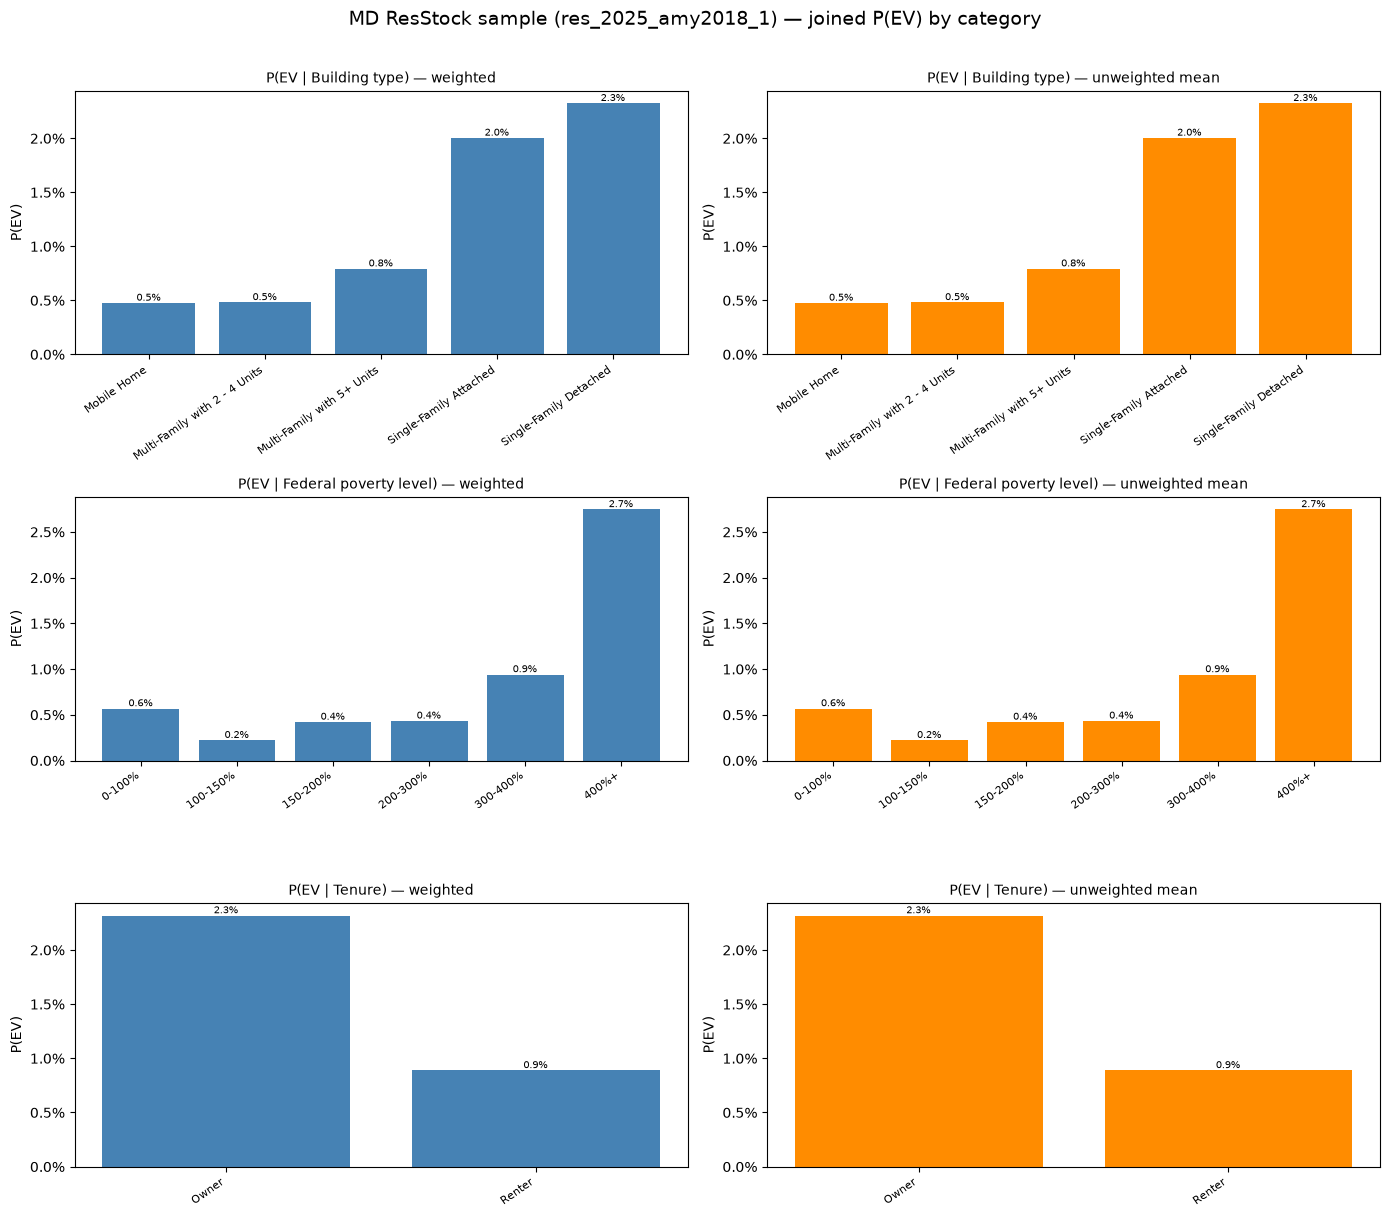

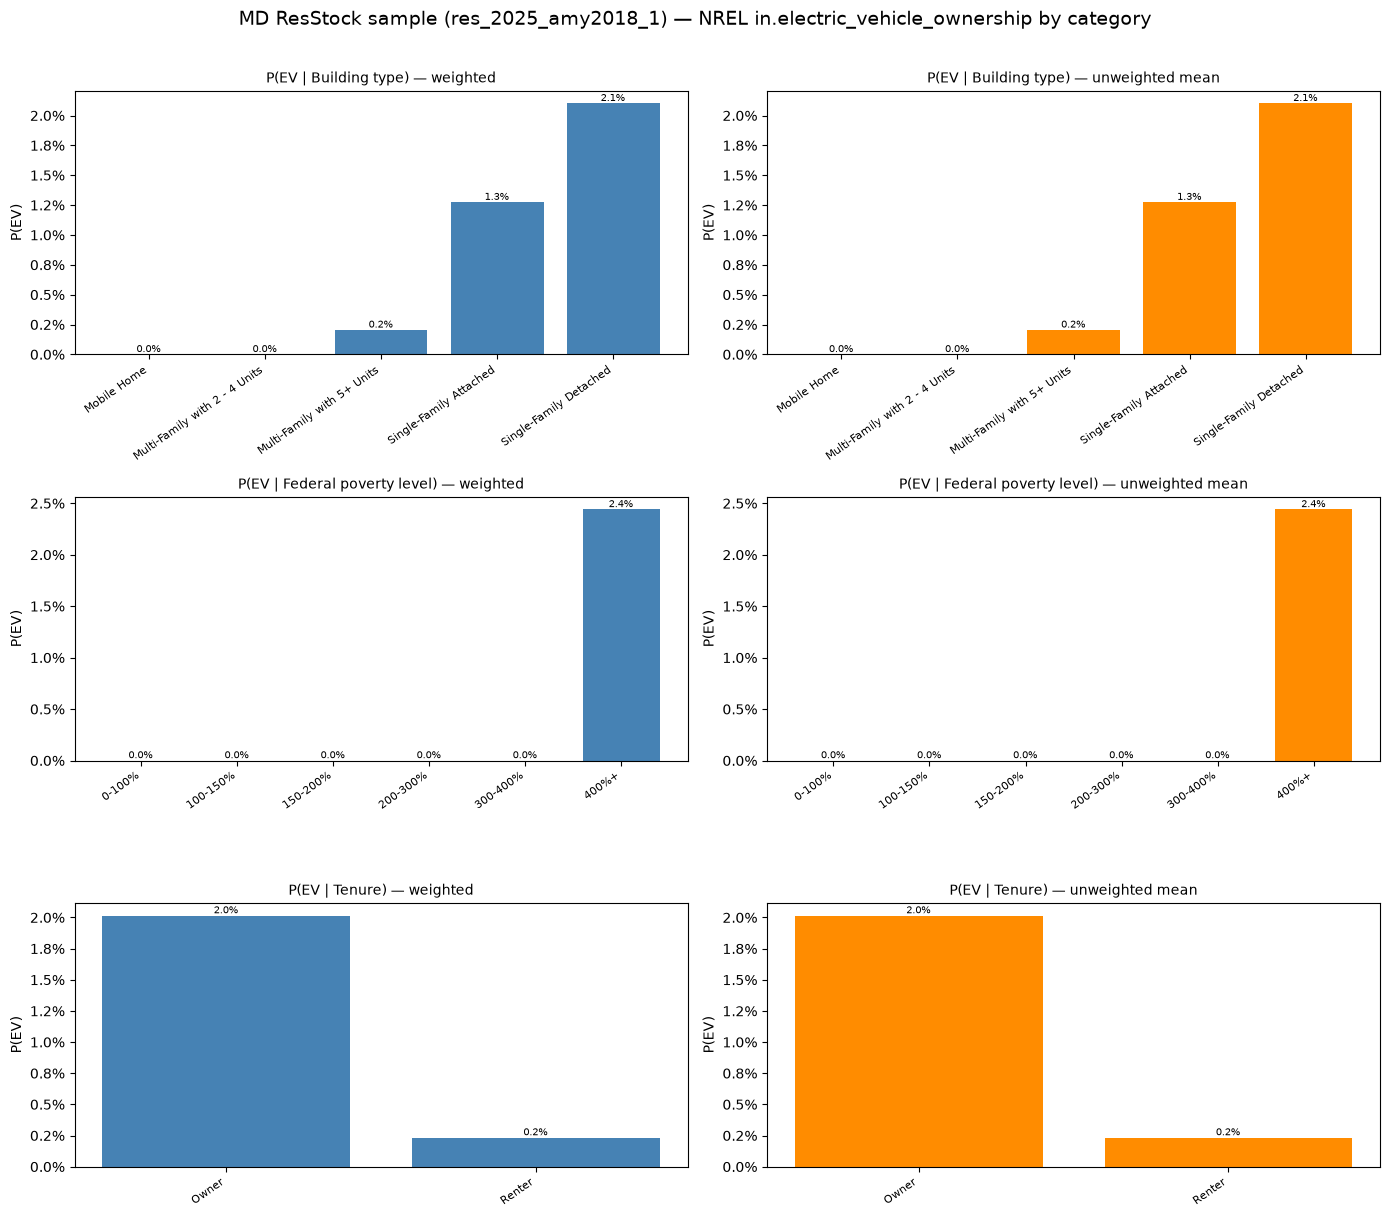

In [ ]:
# Same breakdown on the 2025 MD ResStock release
occ_2025_plot = metadata_2025_prob.filter(~pl.col("is_vacant"))

plot_ev_probs_by_category(
    occ_2025_plot,
    weight_col="weight",
    prob_col="model_p_ev",
    title=f"MD ResStock sample ({RELEASE_2025}) — joined P(EV) by category",
)

plot_ev_probs_by_category(
    occ_2025_plot,
    weight_col="weight",
    prob_col="nrel_has_ev",
    title=f"MD ResStock sample ({RELEASE_2025}) — NREL in.electric_vehicle_ownership by category",
)

In [ ]:
# --- Vacancy check on 2025 (same convention as Step 2) ---
vacant_2025 = metadata_2025.filter(pl.col("in.vacancy_status") == "Vacant")
vacancy_checks_2025 = pl.DataFrame({
    "check": [
        "vacant buildings",
        "vacant with tenure=Not Available AND fpl=Not Available",
        "occupied with tenure=Not Available",
        "occupied with fpl=Not Available",
    ],
    "n": [
        vacant_2025.height,
        vacant_2025.filter(
            (pl.col("in.tenure") == "Not Available")
            & (pl.col("in.federal_poverty_level") == "Not Available")
        ).height,
        metadata_2025.filter(
            (pl.col("in.vacancy_status") == "Occupied")
            & (pl.col("in.tenure") == "Not Available")
        ).height,
        metadata_2025.filter(
            (pl.col("in.vacancy_status") == "Occupied")
            & (pl.col("in.federal_poverty_level") == "Not Available")
        ).height,
    ],
})
print("\n2025 vacancy vs Not Available:")
print(vacancy_checks_2025)

# --- bldg_id overlap: IDs are not stable across releases (TRG §7.3) ---
SEGMENT_KEYS = ["puma_dependency", "fpl", "building_type", "tenure"]

overlap_keys = (
    occ_model.select("bldg_id", *SEGMENT_KEYS)
    .join(
        occ_2025.select(
            "bldg_id",
            pl.col("puma_dependency").alias("puma_25"),
            pl.col("fpl").alias("fpl_25"),
            pl.col("building_type").alias("btype_25"),
            pl.col("tenure").alias("tenure_25"),
        ),
        on="bldg_id",
        how="inner",
    )
    .with_columns(
        pl.all_horizontal([
            pl.col("puma_dependency") == pl.col("puma_25"),
            pl.col("fpl") == pl.col("fpl_25"),
            pl.col("building_type") == pl.col("btype_25"),
            pl.col("tenure") == pl.col("tenure_25"),
        ]).alias("all_keys_match"),
    )
)
print(f"\nOverlapping occupied bldg_ids (2024 ∩ 2025 sample): {overlap_keys.height:,}")
if overlap_keys.height:
    key_mismatch_summary = pl.DataFrame({
        "join_key": ["puma_dependency", "fpl", "building_type", "tenure", "all four keys"],
        "n_mismatch": [
            overlap_keys.filter(pl.col("puma_dependency") != pl.col("puma_25")).height,
            overlap_keys.filter(pl.col("fpl") != pl.col("fpl_25")).height,
            overlap_keys.filter(pl.col("building_type") != pl.col("btype_25")).height,
            overlap_keys.filter(pl.col("tenure") != pl.col("tenure_25")).height,
            overlap_keys.filter(~pl.col("all_keys_match")).height,
        ],
        "n_match": [
            overlap_keys.filter(pl.col("puma_dependency") == pl.col("puma_25")).height,
            overlap_keys.filter(pl.col("fpl") == pl.col("fpl_25")).height,
            overlap_keys.filter(pl.col("building_type") == pl.col("btype_25")).height,
            overlap_keys.filter(pl.col("tenure") == pl.col("tenure_25")).height,
            overlap_keys.filter(pl.col("all_keys_match")).height,
        ],
    }).with_columns(
        (pl.col("n_mismatch") / overlap_keys.height).round(3).alias("share_mismatch"),
    )
    print("\nJoin-key agreement on overlapping bldg_ids (2024 vs 2025 metadata):")
    print(key_mismatch_summary)
    print(
        "\nExample mismatches (same bldg_id, different segment in each release):"
    )
    print(
        overlap_keys.filter(~pl.col("all_keys_match"))
        .head(8)
        .select(
            "bldg_id",
            "puma_dependency", "puma_25",
            "fpl", "fpl_25",
            "building_type", "btype_25",
            "tenure", "tenure_25",
        )
    )


2025 vacancy vs Not Available:
shape: (4, 2)
┌─────────────────────────────────┬─────┐
│ check                           ┆ n   │
│ ---                             ┆ --- │
│ str                             ┆ i64 │
╞═════════════════════════════════╪═════╡
│ vacant buildings                ┆ 986 │
│ vacant with tenure=Not Availab… ┆ 986 │
│ occupied with tenure=Not Avail… ┆ 0   │
│ occupied with fpl=Not Availabl… ┆ 0   │
└─────────────────────────────────┴─────┘

Overlapping occupied bldg_ids (2024 ∩ 2025 sample): 160

Join-key agreement on overlapping bldg_ids (2024 vs 2025 metadata):
shape: (5, 4)
┌─────────────────┬────────────┬─────────┬────────────────┐
│ join_key        ┆ n_mismatch ┆ n_match ┆ share_mismatch │
│ ---             ┆ ---        ┆ ---     ┆ ---            │
│ str             ┆ i64        ┆ i64     ┆ f64            │
╞═════════════════╪════════════╪═════════╪════════════════╡
│ puma_dependency ┆ 154        ┆ 6       ┆ 0.962          │
│ fpl             ┆ 98         ┆ 6

In [ ]:
# --- Segment-level comparison (correct unit: housing segment, not bldg_id) ---
def segment_ev_table(df: pl.DataFrame, prob_col: str, actual_col: str, prefix: str) -> pl.DataFrame:
    return (
        df.group_by(SEGMENT_KEYS)
        .agg(
            pl.len().alias(f"{prefix}_n_bldgs"),
            pl.col(prob_col).sum().round(2).alias(f"{prefix}_expected_ev"),
            pl.col(actual_col).cast(pl.Int32).sum().alias(f"{prefix}_actual_ev"),
        )
        .with_columns(
            (pl.col(f"{prefix}_actual_ev") - pl.col(f"{prefix}_expected_ev"))
            .round(2)
            .alias(f"{prefix}_actual_minus_expected"),
        )
    )

seg_2024 = segment_ev_table(occ_model, "ev_ownership_probability", "has_ev", "y2024")
seg_2025 = segment_ev_table(occ_2025, "model_p_ev", "nrel_has_ev", "y2025")

seg_compare = (
    seg_2024.join(seg_2025, on=SEGMENT_KEYS, how="full", coalesce=True)
    .with_columns(pl.max_horizontal("y2024_n_bldgs", "y2025_n_bldgs").alias("max_n_bldgs"))
    .sort("max_n_bldgs", descending=True)
)

seg_totals = pl.DataFrame({
    "segment": ["ALL occupied (MD)"],
    "y2024_n_bldgs": [occ_model.height],
    "y2024_expected_ev": [round(occ_model["ev_ownership_probability"].sum(), 2)],
    "y2024_actual_ev": [int(occ_model["has_ev"].sum())],
    "y2024_actual_minus_expected": [
        round(occ_model["has_ev"].sum() - occ_model["ev_ownership_probability"].sum(), 2)
    ],
    "y2025_n_bldgs": [occ_2025.height],
    "y2025_expected_ev": [round(occ_2025["model_p_ev"].sum(), 2)],
    "y2025_actual_ev": [int(occ_2025["nrel_has_ev"].sum())],
    "y2025_actual_minus_expected": [
        round(occ_2025["nrel_has_ev"].sum() - occ_2025["model_p_ev"].sum(), 2)
    ],
})

print(
    f"\nSegment-level EV counts (grouped by {', '.join(SEGMENT_KEYS)}); "
    "expected = sum P(EV), actual = sum Yes/has_ev:"
)
print("\nStatewide totals:")

seg_totals


Segment-level EV counts (grouped by puma_dependency, fpl, building_type, tenure); expected = sum P(EV), actual = sum Yes/has_ev:

Statewide totals:


segment,y2024_n_bldgs,y2024_expected_ev,y2024_actual_ev,y2024_actual_minus_expected,y2025_n_bldgs,y2025_expected_ev,y2025_actual_ev,y2025_actual_minus_expected
str,i64,f64,i64,f64,i64,f64,i64,f64
"""ALL occupied (MD)""",9002,165.19,187,21.81,8954,164.65,127,-37.65


In [ ]:
print(f"\nPer-segment rows: {seg_compare.height:,} (showing 15 largest by max sample size)")
seg_compare.head(10).select(
        *SEGMENT_KEYS,
        "y2024_n_bldgs", "y2024_expected_ev", "y2024_actual_ev", "y2024_actual_minus_expected",
        "y2025_n_bldgs", "y2025_expected_ev", "y2025_actual_ev", "y2025_actual_minus_expected",
    )


Per-segment rows: 1,569 (showing 15 largest by max sample size)


puma_dependency,fpl,building_type,tenure,y2024_n_bldgs,y2024_expected_ev,y2024_actual_ev,y2024_actual_minus_expected,y2025_n_bldgs,y2025_expected_ev,y2025_actual_ev,y2025_actual_minus_expected
str,str,str,str,u32,f64,i32,f64,u32,f64,i32,f64
"""MD, 01500""","""400%+""","""Single-Family Detached""","""Owner""",146,2.84,3,0.16,143,2.79,3,0.21
"""MD, 01004""","""400%+""","""Single-Family Detached""","""Owner""",136,7.83,11,3.17,134,7.71,8,0.29
"""MD, 00400""","""400%+""","""Single-Family Detached""","""Owner""",131,2.51,2,-0.51,133,2.55,3,0.45
"""MD, 01105""","""400%+""","""Single-Family Detached""","""Owner""",123,1.87,3,1.13,120,1.82,2,0.18
"""MD, 01001""","""400%+""","""Single-Family Detached""","""Owner""",109,5.14,6,0.86,112,5.28,5,-0.28
"""MD, 01106""","""400%+""","""Single-Family Detached""","""Owner""",103,1.48,1,-0.48,108,1.55,2,0.45
"""MD, 01203""","""400%+""","""Single-Family Detached""","""Owner""",106,3.08,3,-0.08,108,3.13,3,-0.13
"""MD, 00901""","""400%+""","""Single-Family Detached""","""Owner""",108,6.27,6,-0.27,105,6.1,6,-0.1
"""MD, 01300""","""400%+""","""Single-Family Detached""","""Owner""",107,1.8,4,2.2,99,1.66,2,0.34


In [ ]:
def build_gated_ev_load(df: pl.DataFrame) -> pl.DataFrame:
    """Flat miles/kWh model — load only where ev_count > 0."""
    return (
        df.select(
            "bldg_id",
            "weight",
            "is_vacant",
            "in.county_name",
            "in.income",
            "in.puma_metro_status",
            pl.col("in.utility_bill_electricity_marginal_rates").cast(pl.Float64).alias("rate_per_kwh"),
            "has_ev",
            "ev_count",
        )
        .with_columns(
            (pl.lit(DAILY_MILES) * pl.col("ev_count")).alias("daily_miles"),
            (pl.lit(daily_kwh_per_ev) * pl.col("ev_count")).alias("daily_ev_kwh"),
            (pl.lit(annual_kwh_per_ev) * pl.col("ev_count")).alias("annual_ev_kwh"),
        )
        .with_columns(
            (pl.col("daily_miles") * DAYS_PER_YEAR).alias("annual_miles"),
            (pl.col("annual_ev_kwh") * pl.col("rate_per_kwh")).alias("annual_ev_cost_usd"),
        )
        .with_columns(
            (pl.col("annual_ev_kwh") * pl.col("weight")).alias("weighted_annual_ev_kwh"),
            (pl.col("annual_ev_cost_usd") * pl.col("weight")).alias("weighted_annual_ev_cost_usd"),
        )
    )

def summarize_gated_ev_load(
    df: pl.DataFrame,
    *,
    release: str,
    adoption_source: str,
) -> dict:
    occupied = df.filter(~pl.col("is_vacant"))
    ev_owners = df.filter(pl.col("has_ev"))
    total_weight = occupied["weight"].sum()
    return {
        "release": release,
        "adoption_source": adoption_source,
        "n_occupied": occupied.height,
        "n_with_ev": ev_owners.height,
        "adoption_rate": ev_owners.height / occupied.height,
        "weighted_adoption_rate": float(
            (occupied["has_ev"].cast(pl.Float64) * occupied["weight"]).sum() / total_weight
        ),
        "mean_annual_kwh_per_ev_owner": float(ev_owners["annual_ev_kwh"].mean()) if ev_owners.height else 0.0,
        "mean_annual_cost_per_ev_owner": float(ev_owners["annual_ev_cost_usd"].mean()) if ev_owners.height else 0.0,
        "weighted_annual_ev_kwh": float(df["weighted_annual_ev_kwh"].sum()),
        "weighted_annual_ev_cost_usd": float(df["weighted_annual_ev_cost_usd"].sum()),
    }

def print_gated_ev_load_summary(df: pl.DataFrame, *, title: str) -> None:
    occupied = df.filter(~pl.col("is_vacant"))
    ev_owners = df.filter(pl.col("has_ev"))
    total_weight = occupied["weight"].sum()

    print(title)
    print(
        f"  Per-EV assumption: {DAILY_MILES} mi/day × {KWH_PER_MILE} kWh/mi "
        f"= {daily_kwh_per_ev} kWh/day ({annual_kwh_per_ev:,.0f} kWh/yr)"
    )
    print(f"\n  Occupied buildings:     {occupied.height:,}")
    print(f"  With EV:                {ev_owners.height:,} ({ev_owners.height / occupied.height:.2%})")
    print(
        f"  Weighted adoption rate: "
        f"{(occupied['has_ev'].cast(pl.Float64) * occupied['weight']).sum() / total_weight:.2%}"
    )
    if ev_owners.height:
        print(f"\n  Per EV household (owners only):")
        print(f"    Daily miles:  {ev_owners['daily_miles'].mean():,.1f} mi")
        print(f"    Daily kWh:    {ev_owners['daily_ev_kwh'].mean():,.1f}")
        print(f"    Annual kWh:   {ev_owners['annual_ev_kwh'].mean():,.0f}")
        print(f"    Annual cost:  ${ev_owners['annual_ev_cost_usd'].mean():,.0f}")
    print(f"\n  MD represented stock (weighted totals):")
    print(f"    Annual EV kWh:  {df['weighted_annual_ev_kwh'].sum():,.0f}")
    print(f"    Annual EV cost: ${df['weighted_annual_ev_cost_usd'].sum():,.0f}")

# --- 2024: Bernoulli sample from lookup probabilities (cell above) ---
ev_model_adoption_2024 = build_gated_ev_load(metadata_with_ev)
ev_model_adoption = ev_model_adoption_2024  # legacy alias

print_gated_ev_load_summary(
    ev_model_adoption_2024,
    title="2024 — modeled adoption (Bernoulli from lookup P(EV))",
)
ev_model_adoption_2024.filter(pl.col("has_ev")).head(5)

2024 — modeled adoption (Bernoulli from lookup P(EV))
  Per-EV assumption: 30 mi/day × 0.3 kWh/mi = 9.0 kWh/day (3,285 kWh/yr)

  Occupied buildings:     9,002
  With EV:                187 (2.08%)
  Weighted adoption rate: 2.08%

  Per EV household (owners only):
    Daily miles:  30.0 mi
    Daily kWh:    9.0
    Annual kWh:   3,285
    Annual cost:  $428

  MD represented stock (weighted totals):
    Annual EV kWh:  154,987,635
    Annual EV cost: $20,203,004


bldg_id,weight,is_vacant,in.county_name,in.income,in.puma_metro_status,rate_per_kwh,has_ev,ev_count,daily_miles,daily_ev_kwh,annual_ev_kwh,annual_miles,annual_ev_cost_usd,weighted_annual_ev_kwh,weighted_annual_ev_cost_usd
i64,f64,bool,str,str,str,f64,bool,i8,i8,f64,f64,i16,f64,f64,f64
116824,252.301639,false,"""Prince George's County""","""80000-99999""","""In metro area, not/partially i…",0.130352,true,1,30,9.0,3285.0,10950,428.207506,828810.883229,108037.455451
495692,252.301639,false,"""Montgomery County""","""200000+""","""In metro area, not/partially i…",0.130352,true,1,30,9.0,3285.0,10950,428.207506,828810.883229,108037.455451
379361,252.301639,false,"""Montgomery County""","""160000-179999""","""In metro area, not/partially i…",0.130352,true,1,30,9.0,3285.0,10950,428.207506,828810.883229,108037.455451
543097,252.301639,false,"""Anne Arundel County""","""180000-199999""","""In metro area, not/partially i…",0.130352,true,1,30,9.0,3285.0,10950,428.207506,828810.883229,108037.455451
382318,252.301639,false,"""Baltimore County""","""70000-79999""","""In metro area, not/partially i…",0.130352,true,1,30,9.0,3285.0,10950,428.207506,828810.883229,108037.455451


In [ ]:
# --- 2025: NREL quota sample vs our Bernoulli model (same lookup P(EV), same SEED) ---
rng_2025 = np.random.default_rng(SEED)
probs_2025 = metadata_2025_prob["model_p_ev"].to_numpy()
draws_2025 = rng_2025.random(probs_2025.shape[0])
has_ev_2025_modeled = draws_2025 < probs_2025
is_vacant_2025 = metadata_2025_prob["is_vacant"].to_numpy()
ev_count_2025_modeled = np.where(is_vacant_2025, 0, has_ev_2025_modeled.astype(np.int8))

metadata_2025_modeled = metadata_2025_prob.with_columns(
    pl.Series("has_ev", has_ev_2025_modeled),
    pl.Series("ev_count", ev_count_2025_modeled),
)

metadata_2025_nrel = metadata_2025_prob.with_columns(
    pl.col("nrel_has_ev").alias("has_ev"),
    pl.when(pl.col("is_vacant"))
    .then(pl.lit(0, dtype=pl.Int8))
    .otherwise(pl.col("nrel_has_ev").cast(pl.Int8))
    .alias("ev_count"),
)

ev_model_adoption_2025_nrel = build_gated_ev_load(metadata_2025_nrel)
ev_model_adoption_2025_modeled = build_gated_ev_load(metadata_2025_modeled)

print_gated_ev_load_summary(
    ev_model_adoption_2025_nrel,
    title="2025 — NREL in.electric_vehicle_ownership (quota sample)",
)
print()
print_gated_ev_load_summary(
    ev_model_adoption_2025_modeled,
    title="2025 — modeled adoption (Bernoulli from lookup P(EV))",
)

occ_2025 = metadata_2025_prob.filter(~pl.col("is_vacant"))
expected_ev_2025 = float(occ_2025["model_p_ev"].sum())

ev_adoption_load_comparison = pl.DataFrame([
    summarize_gated_ev_load(
        ev_model_adoption_2024,
        release="2024",
        adoption_source="modeled (Bernoulli)",
    ),
    summarize_gated_ev_load(
        ev_model_adoption_2025_nrel,
        release="2025",
        adoption_source="NREL quota sample",
    ),
    summarize_gated_ev_load(
        ev_model_adoption_2025_modeled,
        release="2025",
        adoption_source="modeled (Bernoulli)",
    ),
]).with_columns(
    pl.col("adoption_rate").round(4),
    pl.col("weighted_adoption_rate").round(4),
    pl.col("mean_annual_kwh_per_ev_owner").round(0),
    pl.col("mean_annual_cost_per_ev_owner").round(0),
    pl.col("weighted_annual_ev_kwh").round(0),
    pl.col("weighted_annual_ev_cost_usd").round(0),
)

print("\nSide-by-side comparison (same flat miles/kWh assumptions):")
print(
    ev_adoption_load_comparison.select(
        "release",
        "adoption_source",
        "n_occupied",
        "n_with_ev",
        "adoption_rate",
        "weighted_adoption_rate",
        "weighted_annual_ev_kwh",
        "weighted_annual_ev_cost_usd",
    )
)

nrel_row = ev_adoption_load_comparison.filter(
    (pl.col("release") == "2025") & (pl.col("adoption_source") == "NREL quota sample")
).row(0, named=True)
modeled_row = ev_adoption_load_comparison.filter(
    (pl.col("release") == "2025") & (pl.col("adoption_source") == "modeled (Bernoulli)")
).row(0, named=True)

print("\n2025 NREL vs modeled delta:")
print(f"  Expected EV count (sum P(EV)):  {expected_ev_2025:,.1f}")
print(f"  NREL actual EV count:           {nrel_row['n_with_ev']:,}")
print(f"  Modeled EV count (Bernoulli):   {modeled_row['n_with_ev']:,}")
print(
    f"  Weighted kWh — NREL:            {nrel_row['weighted_annual_ev_kwh']:,.0f}  "
    f"(modeled: {modeled_row['weighted_annual_ev_kwh']:,.0f}, "
    f"Δ {modeled_row['weighted_annual_ev_kwh'] - nrel_row['weighted_annual_ev_kwh']:+,.0f})"
)
print(
    f"  Weighted cost — NREL:           ${nrel_row['weighted_annual_ev_cost_usd']:,.0f}  "
    f"(modeled: ${modeled_row['weighted_annual_ev_cost_usd']:,.0f}, "
    f"Δ ${modeled_row['weighted_annual_ev_cost_usd'] - nrel_row['weighted_annual_ev_cost_usd']:+,.0f})"
)

ev_adoption_load_comparison


2025 — NREL in.electric_vehicle_ownership (quota sample)
  Per-EV assumption: 30 mi/day × 0.3 kWh/mi = 9.0 kWh/day (3,285 kWh/yr)

  Occupied buildings:     8,954
  With EV:                127 (1.42%)
  Weighted adoption rate: 1.42%

  Per EV household (owners only):
    Daily miles:  30.0 mi
    Daily kWh:    9.0
    Annual kWh:   3,285
    Annual cost:  $495

  MD represented stock (weighted totals):
    Annual EV kWh:  105,927,343
    Annual EV cost: $15,946,697

2025 — modeled adoption (Bernoulli from lookup P(EV))
  Per-EV assumption: 30 mi/day × 0.3 kWh/mi = 9.0 kWh/day (3,285 kWh/yr)

  Occupied buildings:     8,954
  With EV:                162 (1.81%)
  Weighted adoption rate: 1.81%

  Per EV household (owners only):
    Daily miles:  30.0 mi
    Daily kWh:    9.0
    Annual kWh:   3,285
    Annual cost:  $495

  MD represented stock (weighted totals):
    Annual EV kWh:  135,119,918
    Annual EV cost: $20,341,456

Side-by-side comparison (same flat miles/kWh assumptions):
sh

release,adoption_source,n_occupied,n_with_ev,adoption_rate,weighted_adoption_rate,mean_annual_kwh_per_ev_owner,mean_annual_cost_per_ev_owner,weighted_annual_ev_kwh,weighted_annual_ev_cost_usd
str,str,i64,i64,f64,f64,f64,f64,f64,f64
"""2024""","""modeled (Bernoulli)""",9002,187,0.0208,0.0208,3285.0,428.0,1.54987635e8,2.0203004e7
"""2025""","""NREL quota sample""",8954,127,0.0142,0.0142,3285.0,495.0,1.05927343e8,1.5946697e7
"""2025""","""modeled (Bernoulli)""",8954,162,0.0181,0.0181,3285.0,495.0,1.35119918e8,2.0341456e7


### PUMS + NHTS model (miles driven among EV owners)

Now that we have **which** households have EVs (`metadata_with_ev.has_ev`), we can layer on:

- **PUMS** → predict total vehicles per household (`predict_num_vehicles`)
- **NHTS** → sample trip schedules and annual miles

ResStock assumes **one BEV per EV household**, so we use `has_ev` as the adoption gate (not `vehicles × 100%`).

**Prerequisites:** `just download-pums-md` and `just download-nhts`

In [ ]:
import sys
from datetime import datetime
from pathlib import Path

# buildstock-fetch EV modules (must come before rate-design-platform on sys.path)
BSF_ROOT = Path("/ebs/home/lily_switch_box/buildstock-fetch")
if str(BSF_ROOT) not in sys.path:
    sys.path.insert(0, str(BSF_ROOT))

from utils import ev_utils
from utils.ev_demand import EVDemandCalculator

PUMS_PATH = BSF_ROOT / "utils/ev_data/inputs/MD_2021_pums_PUMA_HINCP_VEH_NP.csv"
NHTS_PATH = BSF_ROOT / "utils/ev_data/inputs/NHTS_v2_1_trip_surveys.csv"

if not PUMS_PATH.exists():
    raise FileNotFoundError(
        f"Missing {PUMS_PATH}. Run: just download-pums-md"
    )
if not NHTS_PATH.exists():
    raise FileNotFoundError(
        f"Missing {NHTS_PATH}. Run: just download-nhts"
    )

# None = all MD buildings that pass load_metadata filters (~9,002); int = head(N) for fast iteration
N_VEH_SAMPLE: int | None = None

# load_metadata() is slim (vehicle-model columns only); keep full metadata for costs
metadata_slim = ev_utils.load_metadata(path_metadata, STATE)
if N_VEH_SAMPLE is not None:
    metadata_slim = metadata_slim.join(
        metadata.head(N_VEH_SAMPLE).select("bldg_id"), on="bldg_id"
    )
metadata_sample = metadata.join(metadata_slim.select("bldg_id"), on="bldg_id")
pums_df = ev_utils.load_pums_data(str(PUMS_PATH), path_metadata)

print(f"PUMS households: {pums_df.height:,}")
print(f"ResStock sample:   {metadata_slim.height:,}")
print(pums_df.group_by("vehicles").agg(pl.len().alias("n")).sort("vehicles"))

nhts_df = ev_utils.load_nhts_data(str(NHTS_PATH), STATE)
print(f"NHTS trips (MD census division): {nhts_df.height:,}")

PUMS households: 23,776
ResStock sample:   9,002
shape: (7, 2)
┌──────────┬──────┐
│ vehicles ┆ n    │
│ ---      ┆ ---  │
│ i64      ┆ u32  │
╞══════════╪══════╡
│ 0        ┆ 1578 │
│ 1        ┆ 7449 │
│ 2        ┆ 9240 │
│ 3        ┆ 3675 │
│ 4        ┆ 1302 │
│ 5        ┆ 382  │
│ 6        ┆ 150  │
└──────────┴──────┘
NHTS trips (MD census division): 5,352


In [ ]:
SCHEDULE_START = datetime(2024, 1, 1)
SCHEDULE_END = datetime(2024, 12, 31)

# ResStock: one BEV per EV household — use has_ev from the ownership model above
ev_adoption = metadata_with_ev.select("bldg_id", "has_ev", "ev_count", "ev_ownership_probability")

# create EV demand calculator
calculator = EVDemandCalculator(
    metadata_df=metadata_slim,
    nhts_df=nhts_df,
    pums_df=pums_df,
    start_date=SCHEDULE_START,
    end_date=SCHEDULE_END,
    random_state=SEED,
)

bldg_vehicles = calculator.predict_num_vehicles()

print("Predicted vehicles per building")
print(bldg_vehicles.group_by("vehicles").agg(pl.len().alias("buildings")).sort("vehicles"))
print(f"Mean vehicles/household: {bldg_vehicles['vehicles'].mean():.2f}")
print(f"Buildings with EV (ResStock ownership): {ev_adoption['has_ev'].sum():,.0f}")

vehicle_profiles = calculator.sample_vehicle_profiles(bldg_vehicles, nhts_df)
print(f"Vehicle profiles sampled: {len(vehicle_profiles):,}")

trip_schedules = calculator._generate_annual_trip_schedule(vehicle_profiles)
print(f"Trip schedule rows: {trip_schedules.height:,}")
trip_schedules.head(5)

2026-06-14 23:53:43,872 - INFO - Vehicle ownership model not fitted yet. Fitting model...
2026-06-14 23:53:43,911 - INFO - Sampling vehicle profiles for 9002 buildings...
2026-06-14 23:53:43,912 - INFO - Preparing NHTS data cache to optimize matching...
2026-06-14 23:53:43,915 - INFO - NHTS cache prepared successfully


Predicted vehicles per building
shape: (3, 2)
┌──────────┬───────────┐
│ vehicles ┆ buildings │
│ ---      ┆ ---       │
│ i64      ┆ u32       │
╞══════════╪═══════════╡
│ 0        ┆ 6         │
│ 1        ┆ 3022      │
│ 2        ┆ 5974      │
└──────────┴───────────┘
Mean vehicles/household: 1.66


2026-06-14 23:54:01,787 - INFO - Building progress: 9002/9002 (100.0%)
2026-06-14 23:54:01,788 - INFO - Generated 14970 vehicle profiles from 9002 buildings
2026-06-14 23:54:01,791 - INFO - Processing 14970 vehicle profiles...
2026-06-14 23:54:01,792 - INFO - Using parallel processing with all available workers


Vehicle profiles sampled: 14,970
Example bldg 185465 vehicle 1: 2 weekday trips, 0 weekend trips


2026-06-14 23:59:19,077 - INFO - Progress: 10000/14970 (66.8%)
2026-06-15 00:01:56,004 - INFO - Progress: 14970/14970 (100.0%)
2026-06-15 00:01:56,008 - INFO - Generated 12087360 trip schedules from 14970 vehicle profiles


Trip schedule rows: 12,087,360


bldg_id,vehicle_id,date,departure_hour,arrival_hour,miles_driven
i64,i64,datetime[μs],i64,i64,f64
389682,1,2024-01-06 00:00:00,19,19,8.495297
389682,1,2024-01-06 00:00:00,19,19,8.624196
389682,1,2024-01-07 00:00:00,19,21,9.170579
389682,1,2024-01-07 00:00:00,19,18,8.014251
389682,1,2024-01-13 00:00:00,19,19,8.448941


In [ ]:
bldg_annual_miles = (
    trip_schedules.group_by("bldg_id")
    .agg(
        pl.col("miles_driven").sum().alias("annual_miles"),
        pl.col("miles_driven").mean().alias("mean_miles_per_trip"),
        pl.len().alias("trip_count"),
    )
)

ev_model_nhts = (
    metadata_sample.select(
        "bldg_id",
        "weight",
        "in.county_name",
        "in.income",
        "in.utility_bill_electricity_marginal_rates",
    )
    .join(ev_adoption, on="bldg_id")
    .join(bldg_vehicles.select("bldg_id", "vehicles"), on="bldg_id")
    .join(bldg_annual_miles, on="bldg_id", how="left")
    .with_columns(
        pl.col("annual_miles").fill_null(0.0),
        pl.col("trip_count").fill_null(0),
    )
    .rename({"in.utility_bill_electricity_marginal_rates": "rate_per_kwh"})
    .with_columns(
        # Only EV owners drive/charge; ResStock assigns at most one BEV
        pl.when(pl.col("has_ev")).then(pl.col("annual_miles")).otherwise(0.0).alias("ev_annual_miles"),
    )
    .with_columns(
        (pl.col("ev_annual_miles") * KWH_PER_MILE).alias("annual_ev_kwh"),
    )
    .with_columns(
        (pl.col("annual_ev_kwh") / DAYS_PER_YEAR).alias("daily_ev_kwh"),
        (pl.col("annual_ev_kwh") / pl.col("ev_count").clip(lower_bound=1)).alias("annual_ev_kwh_per_ev"),
    )
    .with_columns(
        (pl.col("annual_ev_kwh") * pl.col("rate_per_kwh")).alias("annual_ev_cost_usd"),
        (pl.col("annual_ev_kwh") * pl.col("weight")).alias("weighted_annual_ev_kwh"),
        (pl.col("annual_ev_cost_usd") * pl.col("weight")).alias("weighted_annual_ev_cost_usd"),
    )
)

print("Miles per building (EV owners only)")
ev_owners = ev_model_nhts.filter(pl.col("has_ev"))
print(
    ev_owners.select(
        pl.col("ev_annual_miles").mean().alias("mean"),
        pl.col("ev_annual_miles").median().alias("median"),
        pl.col("ev_annual_miles").max().alias("max"),
    )
)

print("\nComparison (occupied buildings on sample, unweighted annual_ev_kwh totals)")
sample_ids = metadata_sample.select("bldg_id")
simple_on_sample = ev_model_simple.join(sample_ids, on="bldg_id")
resstock_on_sample = ev_model_resstock_adoption.join(sample_ids, on="bldg_id")
print(f"  Simple (1 EV, flat miles):       {simple_on_sample['annual_ev_kwh'].sum():>12,.0f} kWh")
print(f"  ResStock adoption, flat miles:   {resstock_on_sample['annual_ev_kwh'].sum():>12,.0f} kWh")
print(f"  ResStock adoption + NHTS miles:  {ev_model_nhts['annual_ev_kwh'].sum():>12,.0f} kWh")

ev_model_nhts.filter(pl.col("has_ev")).head(10)

Miles per building (sample)
shape: (1, 3)
┌─────────────┬────────────┬───────────────┐
│ mean        ┆ median     ┆ max           │
│ ---         ┆ ---        ┆ ---           │
│ f64         ┆ f64        ┆ f64           │
╞═════════════╪════════════╪═══════════════╡
│ 14336.30104 ┆ 8803.02479 ┆ 291893.632854 │
└─────────────┴────────────┴───────────────┘
Flat-assumption benchmark: 10950 mi/EV/year

Comparison (same buildings, unweighted annual_ev_kwh totals)
  Simple (1 EV, flat miles):    29,571,570 kWh
  PUMS counts, flat miles:      49,176,450 kWh
  PUMS + NHTS trip schedules:   38,716,615 kWh


bldg_id,weight,in.county_name,in.income,rate_per_kwh,vehicles,annual_miles,mean_miles_per_trip,trip_count,ev_count,annual_ev_kwh,daily_ev_kwh,annual_ev_kwh_per_ev,annual_ev_cost_usd,weighted_annual_ev_kwh,weighted_annual_ev_cost_usd
i64,f64,str,str,f64,i64,f64,f64,u32,f64,f64,f64,f64,f64,f64,f64
185465,252.301639,"""Anne Arundel County""","""100000-119999""",0.130352,2,10950.941484,11.649938,940,2.0,3285.282445,9.000774,1642.641223,428.244323,828882.144599,108046.744539
381889,252.301639,"""Prince George's County""","""100000-119999""",0.130352,2,14857.930183,9.45161,1572,2.0,4457.379055,12.211997,2228.689528,581.029884,1.1246e6,146594.791808
294937,252.301639,"""Baltimore city""","""100000-119999""",0.130352,1,7727.493734,14.747125,524,1.0,2318.24812,6.351365,2318.24812,302.189116,584897.799739,76242.80914
310780,252.301639,"""Baltimore County""","""<10000""",0.130352,1,328.743203,0.627373,524,1.0,98.622961,0.2702,98.622961,12.855736,24882.734619,3243.523206
313723,252.301639,"""Harford County""","""50000-59999""",0.130352,1,2368.391222,2.259915,1048,1.0,710.517367,1.946623,710.517367,92.617616,179264.695974,23367.576364
389682,252.301639,"""Baltimore County""","""45000-49999""",0.130352,1,1699.300314,8.169713,208,1.0,509.790094,1.396685,509.790094,66.452342,128620.876192,16766.034886
420703,252.301639,"""Howard County""","""30000-34999""",0.130352,1,1158.572905,2.211017,524,1.0,347.571872,0.952252,347.571872,45.306814,87692.95278,11430.983438
421768,252.301639,"""Anne Arundel County""","""200000+""",0.130352,2,18594.16627,3.942783,4716,2.0,5578.249881,15.282876,2789.124941,727.138042,1.4074e6,183458.119641
429764,252.301639,"""Montgomery County""","""180000-199999""",0.130352,2,8747.979269,13.929903,628,2.0,2624.393781,7.19012,1312.19689,342.095926,662138.851558,86311.36261


In [ ]:
metadata['in.electric_vehicle'].value_counts()

in.electric_vehicle,count
str,u32
"""None""",9996


In [5]:
# 1. Keyword search
patterns = ["vehicle", "ev", "plug", "charge", "utility", "income", "occup", "puma", "county", "weight"]
for pat in patterns:
    hits = [c for c in metadata.columns if pat.lower() in c.lower()]
    if hits:
        print(f"\n--- {pat} ---")
        print(hits)

# 2. Prefix convention
in_cols  = [c for c in metadata.columns if c.startswith("in.")]
out_cols = [c for c in metadata.columns if c.startswith("out.")]
sb_cols  = [c for c in metadata.columns if c.startswith("sb.")]

# 3. Inspect a column
metadata.group_by("in.tenure").agg(pl.len(), pl.col("weight").sum())

# 4. Hourly load endpoints (from a sample parquet)
import glob
sample = pl.read_parquet(glob.glob(f"{path_loads_dir}/*.parquet")[0], n_rows=1)
[c for c in sample.columns if "electricity" in c]


--- vehicle ---
['in.electric_vehicle']

--- ev ---
['in.clothes_dryer_usage_level', 'in.clothes_washer_usage_level', 'in.cooking_range_usage_level', 'in.dishwasher_usage_level', 'in.federal_poverty_level', 'in.geometry_building_level_mf', 'in.refrigerator_usage_level', 'in.usage_level']

--- plug ---
['in.plug_load_diversity', 'in.plug_loads']

--- charge ---
['in.hvac_system_single_speed_ac_charge', 'in.hvac_system_single_speed_ashp_charge', 'in.utility_bill_electricity_fixed_charges', 'in.utility_bill_fuel_oil_fixed_charges', 'in.utility_bill_natural_gas_fixed_charges', 'in.utility_bill_propane_fixed_charges']

--- utility ---
['in.utility_bill_electricity_fixed_charges', 'in.utility_bill_electricity_marginal_rates', 'in.utility_bill_fuel_oil_fixed_charges', 'in.utility_bill_fuel_oil_marginal_rates', 'in.utility_bill_natural_gas_fixed_charges', 'in.utility_bill_natural_gas_marginal_rates', 'in.utility_bill_propane_fixed_charges', 'in.utility_bill_propane_marginal_rates', 'in.utilit

['out.electricity.ceiling_fan.energy_consumption',
 'out.electricity.ceiling_fan.energy_consumption_intensity',
 'out.electricity.clothes_dryer.energy_consumption',
 'out.electricity.clothes_dryer.energy_consumption_intensity',
 'out.electricity.clothes_washer.energy_consumption',
 'out.electricity.clothes_washer.energy_consumption_intensity',
 'out.electricity.cooling.energy_consumption',
 'out.electricity.cooling.energy_consumption_intensity',
 'out.electricity.cooling_fans_pumps.energy_consumption',
 'out.electricity.cooling_fans_pumps.energy_consumption_intensity',
 'out.electricity.dishwasher.energy_consumption',
 'out.electricity.dishwasher.energy_consumption_intensity',
 'out.electricity.freezer.energy_consumption',
 'out.electricity.freezer.energy_consumption_intensity',
 'out.electricity.heating.energy_consumption',
 'out.electricity.heating.energy_consumption_intensity',
 'out.electricity.heating_fans_pumps.energy_consumption',
 'out.electricity.heating_fans_pumps.energy_cons